# Risco de diabetes – STEPS Moçambique (2005 + 2014)

Notebook que percorre o pipeline completo: **dados → exploração → modelos → avaliação → interpretação**.
Reutiliza `steps_data.py` (harmonização) e `train.py` (definição dos modelos), por isso o notebook e a API usam exactamente a mesma lógica.

> Os CSV brutos (`data/raw/`) contêm identificadores pessoais e não são versionados. Se não existirem, o notebook usa o dataset já processado em `data/processed/`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix)
from sklearn.calibration import calibration_curve

from steps_data import FEATURES, TARGET, GLUCOSE_THRESHOLD, build_dataset
from train import make_models, calibrated, threshold_for_sensitivity, evaluate, SEED, TARGET_SENSITIVITY

pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. Dados

In [2]:
PROCESSED = Path("data/processed/steps_mozambique_2005_2014.csv")
RAW = Path("data/raw")
if RAW.exists() and any(RAW.glob("*.csv")):
    df = build_dataset(RAW)          # refaz a harmonização a partir dos brutos
else:
    df = pd.read_csv(PROCESSED)
print(df.shape)
df.head()

(4882, 25)


,age,sex_male,education_years,height_cm,weight_kg,bmi,waist_cm,waist_height_ratio,sbp,dbp,bp_meds,told_hypertension,smoker_current,smokeless_current,alcohol_past12m,alcohol_days_month,fruit_servings_day,veg_servings_day,met_min_week,sedentary_hours_day,survey_year,glucose_mmol,fasted,diagnosed_diabetes,diabetes
0,43.0,1.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,0.5,2.857143,1.714286,18000.0,2.0,2005,NaN,NaN,0.0,0.0
1,42.0,0.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.000000,2.000000,10312.0,NaN,2005,NaN,NaN,0.0,0.0
2,37.0,0.0,1.0,153.000000,50.500000,21.572899,75.099998,0.490850,115.5,70.5,0.0,0.0,0.0,0.0,0.0,0.0,0.571429,2.000000,12720.0,3.0,2005,NaN,1.0,0.0,0.0
3,47.0,1.0,3.0,156.199997,57.599998,23.608067,81.099998,0.519206,165.5,88.5,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.571429,35040.0,2.0,2005,NaN,1.0,0.0,0.0
4,53.0,0.0,0.0,156.300003,57.700001,23.618801,77.199997,0.493922,142.0,70.5,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2.000000,0.0,NaN,2005,NaN,NaN,0.0,0.0


**Alvo (`diabetes`)** = 1 se glicemia capilar em jejum ≥ `GLUCOSE_THRESHOLD` (6,1 mmol/L, critério OMS STEPS) **ou** diagnóstico médico de diabetes.
A glicemia e as variáveis de diagnóstico **não** são usadas como features (evita fuga de informação): é um modelo de rastreio sem análise de sangue.

In [3]:
resumo = df.groupby("survey_year")[TARGET].agg(n="size", positivos="sum", prevalencia="mean")
resumo["prevalencia"] = (resumo["prevalencia"] * 100).round(1)
resumo.loc["Total"] = [len(df), df[TARGET].sum(), round(df[TARGET].mean() * 100, 1)]
resumo

,n,positivos,prevalencia
survey_year,,,
2005,3195.0,85.0,2.7
2014,1687.0,157.0,9.3
Total,4882.0,242.0,5.0


### Valores em falta (% por vaga)

In [4]:
(df.groupby("survey_year")[FEATURES].agg(lambda s: s.isna().mean()).T * 100).round(1)

survey_year,2005,2014
age,0.0,0.0
sex_male,0.0,0.0
education_years,0.8,27.6
height_cm,7.1,1.2
weight_kg,7.2,1.3
bmi,7.3,1.6
waist_cm,8.1,0.9
waist_height_ratio,8.4,1.4
sbp,7.2,0.6
dbp,7.2,0.6


## 2. Exploração

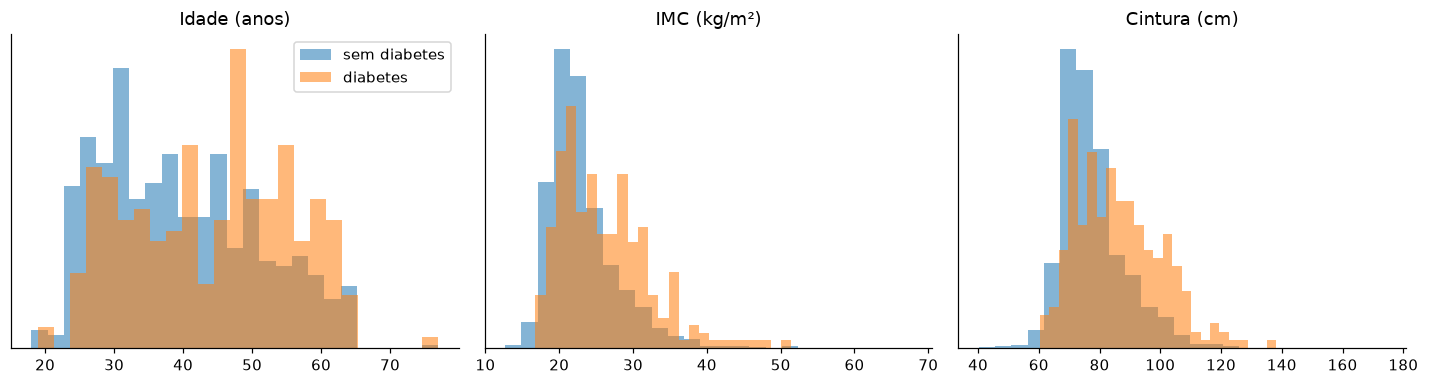

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for a, col, titulo in zip(ax, ["age", "bmi", "waist_cm"], ["Idade (anos)", "IMC (kg/m²)", "Cintura (cm)"]):
    for v, g in df.groupby(TARGET):
        a.hist(g[col].dropna(), bins=25, alpha=.55, density=True, label="diabetes" if v else "sem diabetes")
    a.set_title(titulo); a.set_yticks([])
ax[0].legend(); plt.tight_layout(); plt.show()

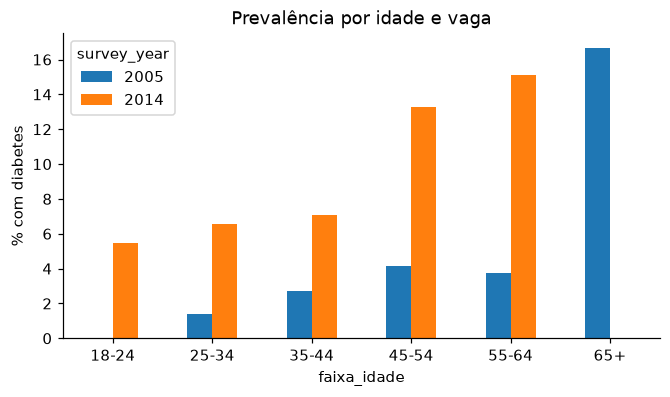

In [6]:
# Prevalência por grupo etário e por vaga
df["faixa_idade"] = pd.cut(df["age"], [17, 24, 34, 44, 54, 64, 120], labels=["18-24","25-34","35-44","45-54","55-64","65+"])
p = df.pivot_table(index="faixa_idade", columns="survey_year", values=TARGET, aggfunc="mean") * 100
p.plot(kind="bar", figsize=(7, 3.6), rot=0); plt.ylabel("% com diabetes"); plt.title("Prevalência por idade e vaga"); plt.show()
df.drop(columns="faixa_idade", inplace=True)

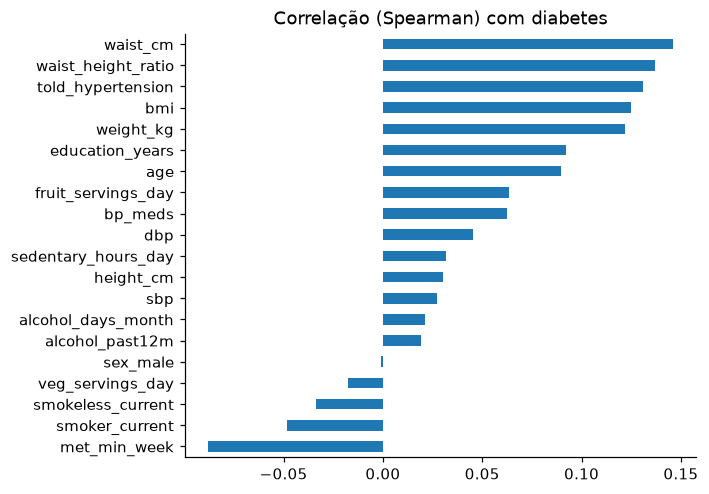

In [7]:
# Correlação das features com o alvo (Spearman)
corr = df[FEATURES + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET).sort_values()
corr.plot(kind="barh", figsize=(6, 5)); plt.title("Correlação (Spearman) com diabetes"); plt.show()

### Atenção: a glicemia mudou entre vagas
As medianas de glicemia (e portanto a prevalência) diferem muito entre 2005 e 2014, o que aponta para diferenças de aparelho/calibração e limita a generalização entre vagas.

In [8]:
g = df[df["fasted"] == 1].groupby("survey_year")["glucose_mmol"]
pd.DataFrame({"mediana": g.median(), "% >= limiar": g.apply(lambda s: (s >= GLUCOSE_THRESHOLD).mean() * 100)}).round(2)

,mediana,% >= limiar
survey_year,,
2005,3.7,2.68
2014,4.6,11.94


## 3. Modelagem
- Hold-out de 20 % (estratificado por vaga × alvo) **antes** de qualquer imputação/escala.
- Os dados **não são balanceados** (prevalência 5 % mantida): usa-se ponderação de classes + calibração sigmoide.
- O limiar de rastreio é escolhido por validação cruzada no treino para uma sensibilidade-alvo de 80 %.

In [9]:
X, y, year = df[FEATURES], df[TARGET].astype(int), df["survey_year"]
strat = year.astype(str) + "_" + y.astype(str)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=strat, random_state=SEED)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"treino={len(X_tr)} (positivos {y_tr.sum()}) | teste={len(X_te)} (positivos {y_te.sum()})")

treino=3905 (positivos 193) | teste=977 (positivos 49)


In [10]:
resultados, probs_te, limiares = {}, {}, {}
for nome, pipe in make_models().items():
    oof = cross_val_predict(calibrated(pipe), X_tr, y_tr, cv=skf, method="predict_proba")[:, 1]
    thr = threshold_for_sensitivity(y_tr.values, oof, TARGET_SENSITIVITY)
    p_te = calibrated(pipe).fit(X_tr, y_tr).predict_proba(X_te)[:, 1]
    probs_te[nome], limiares[nome] = p_te, thr
    resultados[nome] = {"AUC (CV)": roc_auc_score(y_tr, oof), **{k: v for k, v in evaluate(y_te.values, p_te, thr).items()
                        if k in ("roc_auc", "pr_auc", "brier", "sensitivity", "specificity", "precision", "threshold")}}
tabela = pd.DataFrame(resultados).T.rename(columns={"roc_auc": "AUC (teste)", "pr_auc": "PR-AUC", "brier": "Brier",
        "sensitivity": "Sensib.", "specificity": "Especif.", "precision": "Precisão", "threshold": "Limiar"})
tabela.round(3)

,AUC (CV),AUC (teste),PR-AUC,Brier,Limiar,Sensib.,Especif.,Precisão
lr,0.725,0.755,0.152,0.046,0.034,0.816,0.468,0.075
rf,0.714,0.761,0.227,0.044,0.034,0.816,0.500,0.079
lgbm,0.703,0.742,0.190,0.045,0.036,0.857,0.480,0.080
xgb,0.705,0.749,0.200,0.045,0.038,0.837,0.505,0.082


## 4. Avaliação no hold-out

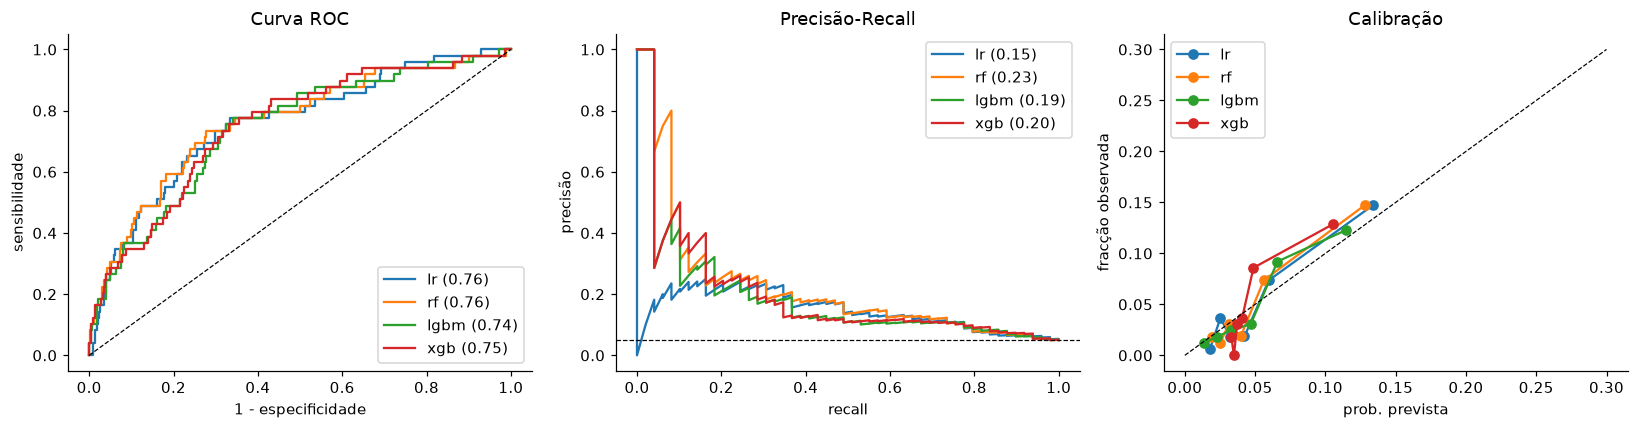

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for nome, p in probs_te.items():
    fpr, tpr, _ = roc_curve(y_te, p); ax[0].plot(fpr, tpr, label=f"{nome} ({roc_auc_score(y_te, p):.2f})")
    pr, rc, _ = precision_recall_curve(y_te, p); ax[1].plot(rc, pr, label=f"{nome} ({average_precision_score(y_te, p):.2f})")
    fo, mp = calibration_curve(y_te, p, n_bins=6, strategy="quantile"); ax[2].plot(mp, fo, "o-", label=nome)
ax[0].plot([0, 1], [0, 1], "k--", lw=.8); ax[0].set(title="Curva ROC", xlabel="1 - especificidade", ylabel="sensibilidade")
ax[1].axhline(y_te.mean(), color="k", ls="--", lw=.8); ax[1].set(title="Precisão-Recall", xlabel="recall", ylabel="precisão")
ax[2].plot([0, .3], [0, .3], "k--", lw=.8); ax[2].set(title="Calibração", xlabel="prob. prevista", ylabel="fracção observada")
for a in ax: a.legend()
plt.tight_layout(); plt.show()

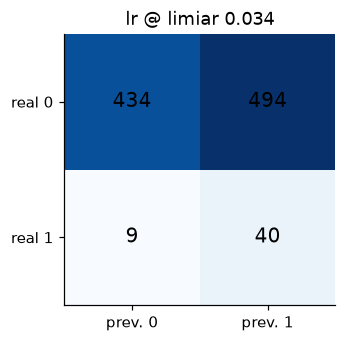

In [12]:
# Matriz de confusão no limiar de rastreio (regressão logística)
nome = "lr"
cm = confusion_matrix(y_te, (probs_te[nome] >= limiares[nome]).astype(int))
fig, a = plt.subplots(figsize=(3.6, 3.2))
a.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm): a.text(j, i, v, ha="center", va="center", fontsize=13)
a.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["prev. 0", "prev. 1"], yticklabels=["real 0", "real 1"],
      title=f"{nome} @ limiar {limiares[nome]:.3f}")
plt.show()

### Generalização entre vagas
Treina numa vaga e testa na outra. Valores mais baixos que no hold-out reflectem as diferenças de medição/população entre 2005 e 2014.

In [13]:
linhas = []
for nome, pipe in make_models().items():
    for src, dst in ((2005, 2014), (2014, 2005)):
        m = calibrated(pipe).fit(X[year == src], y[year == src])
        p = m.predict_proba(X[year == dst])[:, 1]
        linhas.append({"modelo": nome, "treino→teste": f"{src}→{dst}",
                       "AUC": roc_auc_score(y[year == dst], p), "PR-AUC": average_precision_score(y[year == dst], p)})
pd.DataFrame(linhas).pivot(index="modelo", columns="treino→teste", values=["AUC", "PR-AUC"]).round(3)

AUC              PR-AUC          
treino→teste 2005→2014 2014→2005 2005→2014 2014→2005
modelo                                              
lgbm             0.625     0.657     0.166     0.057
lr               0.669     0.711     0.167     0.109
rf               0.648     0.707     0.179     0.093
xgb              0.647     0.696     0.173     0.078

## 5. Interpretação

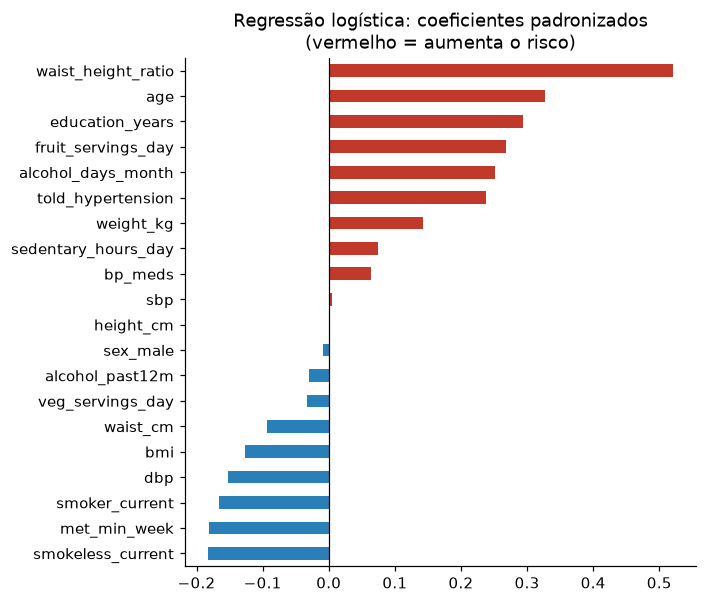

In [14]:
# Coeficientes da regressão logística (features padronizadas -> comparáveis entre si)
lr = make_models()["lr"].fit(X_tr, y_tr)
coef = pd.Series(lr.named_steps["model"].coef_[0], index=FEATURES).sort_values()
coef.plot(kind="barh", figsize=(6, 6), color=np.where(coef > 0, "#c0392b", "#2980b9"))
plt.axvline(0, color="k", lw=.8); plt.title("Regressão logística: coeficientes padronizados\n(vermelho = aumenta o risco)"); plt.show()

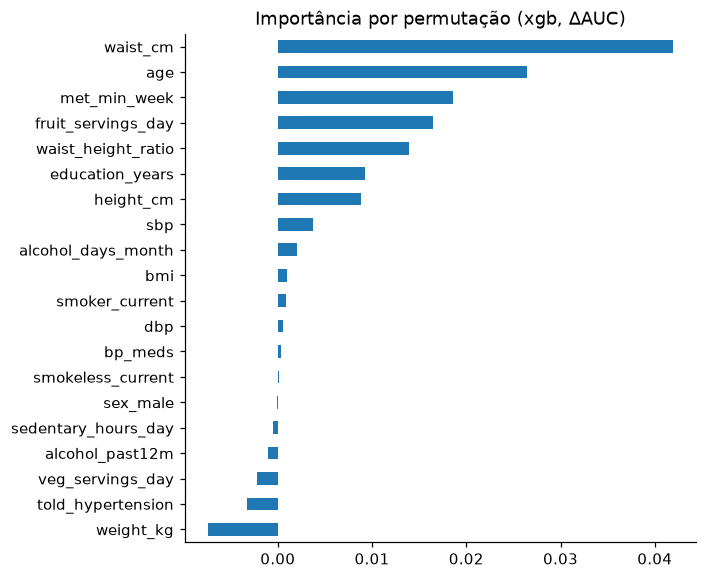

In [15]:
# Importância por permutação (ROC-AUC) no hold-out, em modelo não calibrado (xgb)
from sklearn.inspection import permutation_importance
xgb = make_models()["xgb"].fit(X_tr, y_tr)
pi = permutation_importance(xgb, X_te, y_te, scoring="roc_auc", n_repeats=20, random_state=SEED)
pd.Series(pi.importances_mean, index=FEATURES).sort_values().plot(kind="barh", figsize=(6, 6))
plt.title("Importância por permutação (xgb, ΔAUC)"); plt.show()

## 6. Exemplo de predição (igual à API)

In [16]:
import joblib, json
modelo = joblib.load("models/pipeline_lr.pkl")
meta = json.load(open("models/model_meta.json"))
exemplo = pd.DataFrame([dict.fromkeys(FEATURES, np.nan) | {
    "age": 55, "sex_male": 0, "height_cm": 160, "weight_kg": 85, "waist_cm": 102,
    "sbp": 150, "dbp": 95, "told_hypertension": 1, "bmi": 85 / 1.6**2, "waist_height_ratio": 102 / 160}])[FEATURES]
p = modelo.predict_proba(exemplo)[0, 1]
t = meta["models"]["lr"]
nivel = "alto" if p >= t["high_risk_threshold"] else "médio" if p >= t["screening_threshold"] else "baixo"
print(f"risco = {p:.1%} | nível = {nivel} | limiares: rastreio {t['screening_threshold']:.3f}, alto {t['high_risk_threshold']:.3f}")

risco = 17.4% | nível = alto | limiares: rastreio 0.034, alto 0.084


## Limitações
- Apenas 242 positivos: intervalos de confiança largos; resultados indicativos, não para uso clínico.
- A glicemia difere entre vagas (aparelho/calibração), o que reduz o desempenho entre vagas.
- Significado de várias colunas de 2014 foi inferido (não havia questionário de 2014); ver `README.md`.
- Pesos amostrais, região e área (urbano/rural) não são usados.